# Practical 1: The Bayesian Data Assimilation Cycle

## 1. Introduction

In **Data Assimilation (DA)**, we seek to combine a mathematical model of a physical system with a sequence of noisy, incomplete observations to arrive at the best possible estimate of the system's state. In this practical, we apply the Bayesian framework discussed in Lecture 1 to a single pendulum. 

While the state space here is only 2-dimensional, this "toy problem" perfectly illustrates the computational and conceptual challenges found in global weather and climate models, where state spaces can exceed $10^9$ dimensions.

### Objectives
Your task is to implement a complete Data Assimilation cycle consisting of three phases:

1.  **The Assimilation Loop**: You will alternate between **Forecast** (evolving the PDF forward in time) and **Analysis** (updating the PDF using Bayes' Theorem) to ingest a sequence of noisy observations.
2.  **The Forecast**: Once the last observation is assimilated, you will evolve the resulting posterior PDF into the future to see how uncertainty grows when no data is available to constrain the system.
3.  **The Reanalysis**: You will take your final "best estimate" and push it back through the dynamics to the initial time $t=0$. This allows you to reconstruct the history of the system and refine your knowledge of the starting conditions.



### The Toolkit
We utilize the `qces` sub-module within the `pygeoinf` library, which provides the necessary engines for non-linear physics and grid-based Bayesian updates:
* `pendulum.single.generate_synthetic_data`: Generates a "true" trajectory and noisy samples.
* `pendulum.single.advect_pdf`: Uses Liouville's Theorem to propagate probability mass through the phase space.
* `pendulum.bayesian_update`: Implements the Analysis step ($Posterior \propto Likelihood \times Prior$).
* `pendulum.get_pdf_from_grid`: A utility to interpolate discrete grid results back into callable functions for the next step.





## Generating Synthetic Data

To evaluate our data assimilation scheme, we first need a "ground truth" trajectory to simulate the real physical state of the pendulum. We then sample this truth at discrete intervals and add Gaussian noise to simulate the limitations of real-world sensors.In this exercise, we assume we can only observe the 
angle ($\theta$) of the pendulum. This leaves the momentum ($p$) as a hidden variable that the assimilation process  must infer through the dynamics of the system.

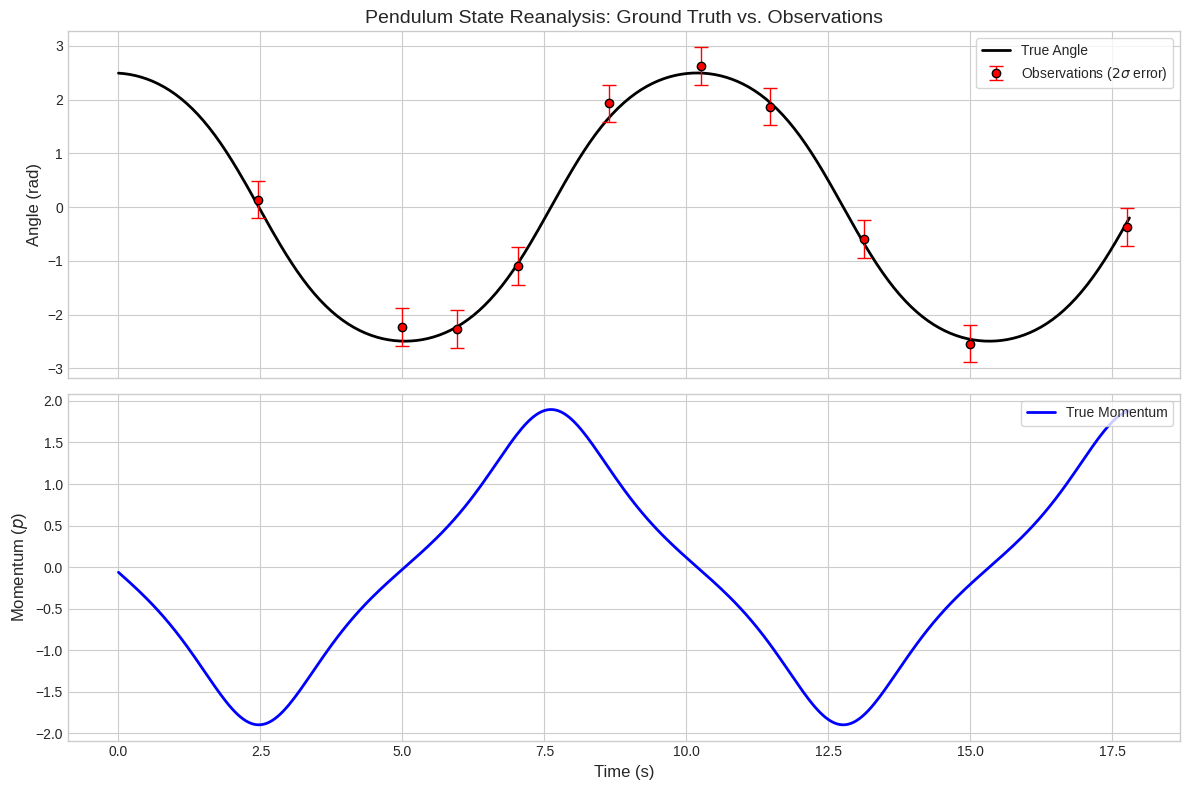

In [85]:
# Import pygeoinf (installing if needed)
try:
    from pygeoinf.qces import pendulum
except ImportError:
    %pip install pygeoinf --quiet
    from pygeoinf.qces import pendulum

# Other imports that are needed
import numpy as np
import matplotlib.pyplot as plt


# Set up the observation times
n_obs = 10                           # Number of observations
t_start = 1.0                        # Earliest possible observation
t_end = 20.0                         # Latest possible observation
dt_min = 0.5*(t_end-t_start)/n_obs   # Minimum allowed spacing between observations

# Generate the observation times
raw_times = np.random.uniform(t_start, t_end - (n_obs - 1) * dt_min, size=n_obs)
raw_times.sort()
t_obs = raw_times + np.arange(n_obs) * dt_min

# Set the observational noise
obs_noise_std = np.deg2rad(10)

# Define the Distribution for the "True" Initial State
prior_mean = [np.deg2rad(130), 0.0]
prior_cov = np.array([[0.2, 0.0], [0.0, 0.2]])

# Generate Synthetic Truth and Data
synthetic_data = pendulum.single.generate_synthetic_data(
    t_obs=t_obs,
    prior_mean=prior_mean,
    prior_cov=prior_cov,
    obs_noise_std=obs_noise_std,
    seed=42
)

# extract the observed values
data = synthetic_data["observations"]

# Extract values for plotting
t_true = synthetic_data["t_ground_truth"]
y_true = synthetic_data["state_ground_truth"]
obs_values = synthetic_data["observations"]

# Plot the data plus the true state evolution
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)


ax1.plot(t_true, y_true[0], color='black', linewidth=2, label='True Angle')
ax1.errorbar(t_obs, obs_values, yerr=2*obs_noise_std, fmt='o', color='red', 
             ecolor='red', capsize=5, elinewidth=1, markeredgecolor='black',
             label='Observations ($2\sigma$ error)')
ax1.set_ylabel('Angle (rad)', fontsize=12)
ax1.set_title('Pendulum State Reanalysis: Ground Truth vs. Observations', fontsize=14)
ax1.legend(loc='upper right', frameon=True)


ax2.plot(t_true, y_true[1], color='blue', linewidth=2, label='True Momentum')
ax2.set_ylabel('Momentum ($p$)', fontsize=12)
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

## Exercise 1: Building the Assimilation Loop

With our synthetic data generated, your first task is to implement the **sequential Bayesian assimilation loop**. This loop is the engine of most modern data assimilation systems. For every observation time $t_i$, you must perform two fundamental operations:

1.  **Forecast (Prediction)**: Evolve your current knowledge (the posterior from the previous time step) forward to the current time using the non-linear physics of the pendulum. This evolved PDF becomes your **prior** for the current analysis.
2.  **Analysis**: Use the new observation to update your prior PDF via Bayes' Theorem, resulting in a new **posterior**.

### Required Functions
You will need the following tools from the `pygeoinf.qces.pendulum` module:
* `single.advect_pdf(pdf_func, t_final, res)`: Propagates a PDF function forward by a time interval `t_final`.
* `LinearGaussianLikelihood(y_obs, R, G)`: Defines the observation model.
* `bayesian_update(prior_grid, likelihood_grid, axes)`: Performs the Bayesian multiplication and normalization.
* `get_pdf_from_grid(axes, grid)`: Converts the discrete results of an update back into a callable function for the next forecast step.


### Implementation Steps
* Initialize your starting belief at $t=0$ as a Gaussian PDF.
* Iterate through the observation times in `t_obs`.
* Store the `prior` and `posterior` grids at each step in a list so you can visualize the "filtering" process later.

<Figure size 800x600 with 0 Axes>

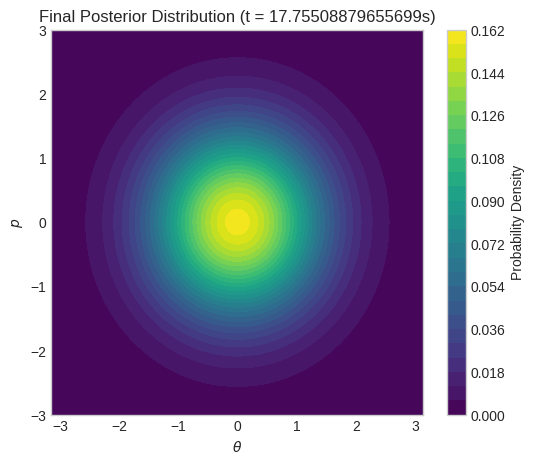

In [ ]:
def run_assimilation(t_obs, obs_values, obs_std, initial_prior_func, res=150):
    """
    Performs sequential Bayesian data assimilation for a single pendulum.
    """    
    

    # Evaluate the initial prior on a grid
    theta_limits = (-np.pi, np.pi)
    p_limits = (-3, 3)
    axes, prior = pendulum.evaluate_pdf_on_grid(
        initial_prior_func, 
        (theta_limits, p_limits), 
        res
        )

    # Define the observation operator (G) and covariance (R)
    # We only observe the angle (index 0), not momentum (index 1)
    G = [[1.0, 0.0]]
    R = [[obs_std**2]]


    t_prev = 0.0
    for i in range(len(t_obs)):
        t_now = t_obs[i]
        y_obs = [obs_values[i]]
        dt = t_now - t_prev
        
        # 1. FORECAST STEP: Predict the state at t_now
        prior_func = pendulum.get_pdf_from_grid(axes, prior)
        _, _, _, prior = pendulum.single.advect_pdf(prior_func, dt, res=res)
        
        
        # 2. ANALYSIS STEP: Update the prior with the observation
        lik_model = pendulum.LinearGaussianLikelihood(
            observation_value=y_obs, 
            observation_covariance=R, 
            observation_matrix=G
        )
    likelihood = lik_model.evaluate(state_grid)
posterior_t2, evidence_t2 = pendulum.bayesian_update(prior_t2, likelihood, axes_1d)

        
        # Evaluate the likelihood on the state grid
        
        
        # Perform the bayesian_update
        
                
        
        # Update for the next iteration
        
        
    posterior = prior    
    return axes, posterior

# --- Test the Implementation ---


# 1. Define a starting prior at t=0 (Broad Gaussian)
init_mean = [0.0, 0.0]
init_cov = np.diag([1.0, 1.0])
initial_prior = pendulum.get_gaussian_pdf_func(mean=init_mean, cov=init_cov)

# 2. Run the Assimilation
axes, final_posterior = run_assimilation(
    t_obs, obs_values, obs_noise_std, initial_prior, res=150
)



# 3. Plot the final posterior at the last observation time
theta_grid, p_grid = np.meshgrid(axes[0], axes[1], indexing='ij')

plt.figure(figsize=(8, 6))
# Reuse the plotting tool from the library
_, cont = pendulum.single.plot_pdf(theta_grid, p_grid, final_post)
plt.colorbar(cont, label='Probability Density')

# Add the true state for comparison
#true_final_state = y_true[:, -1]
#plt.plot(true_final_state[0], true_final_state[1], 'r*', markersize=15, label='True State')

plt.title(f'Final Posterior Distribution (t = {t_obs[-1]}s)')
#plt.legend()
plt.show()
